<a href="https://colab.research.google.com/github/SNEHA-ABC123/FINAL-PYML-INTERNSHIP-2025/blob/main/ML_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 ML Project: Crime Risk Assessment Against Women in Indian States

🎯 Objective To assess and classify Indian states based on the severity of crimes against women using ML.

📁 Dataset Source: IndiaDataPortal (District-wise crime statistics)

Project by:
1. Shravyaa Gupta (19801012024)
2. Sneha rakheja (20601012024)

from: **IGDTUW**

1. IMPORTING LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the dependencies

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import shap

 Mounting the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. LOADING DATA

In [ ]:
df = pd.read_csv("/content/districtwise-crime-against-women-2017-onwards.csv")
pd.set_option('display.max_columns', None)

3. CLEANING DATA(dropping some columns)

In [ ]:
drop_cols = [
    'id','state_code','district_code','registration_circles',
    'pocso_act_unnatural_offences','offences_of_pocso_act',
    'use_of_child_for_pornography','child_sexual_harassment',
    'sexual_assault_of_children','child_rape'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

4. GROUPING CRIME CATEGORIES

In [ ]:
crime_groups = {
    "Sexual_Offences": [
        'rape', 'assault_on_women_with_intent_to_outrage_modesty',
        'sexual_harassment', 'attempt_to_commit_rape'
    ],
    "Domestic_Violence": [
        'cruelty_by_husband_or_his_relatives','dowry_deaths','dowry_prohibition_act'
    ],
    "Trafficking": [
        'human_trafficking','immoral_traffic_prevention_act'
    ],
    "Other_Crimes": [
        'acid_attack','insult_to_modesty_of_women','indecent_representation_of_women'
    ]
}

# Check available columns and update crime_groups
available_cols = df.columns.tolist()
updated_crime_groups = {}
for group, cols in crime_groups.items():
    updated_cols = [col for col in cols if col in available_cols]
    if updated_cols:
        updated_crime_groups[group] = updated_cols
    else:
        print(f"Warning: None of the columns for group '{group}' were found in the DataFrame.")

# Sum grouped columns
for group, cols in updated_crime_groups.items():
    df[group] = df[cols].sum(axis=1, numeric_only=True)

# Drop original grouped columns to avoid duplication
all_grouped_cols = [c for cols in updated_crime_groups.values() for c in cols]
df.drop(columns=all_grouped_cols, inplace=True, errors='ignore')

5. AGGREGATE AT STATE-YEAR LEVEL

In [ ]:
gdf = df.groupby(['year','state_name'], as_index=False).sum(numeric_only=True)

6. RISK LEVEL CLASSIFICATION

In [ ]:
gdf['total_crimes'] = gdf.iloc[:, 2:].sum(axis=1)
mean_val = gdf['total_crimes'].mean()
std_val = gdf['total_crimes'].std()

def classify_risk(crime_count):
    if crime_count <= mean_val - std_val:
        return 'Low'
    elif crime_count <= mean_val + std_val:
        return 'Medium'
    else:
        return 'High'

gdf['Risk_Level'] = gdf['total_crimes'].apply(classify_risk)

7. TRAIN-TEST SPLIT

In [ ]:
X = gdf.drop(columns=['state_name','year','Risk_Level', 'total_crimes'])
y = gdf['Risk_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

8. RANDOM FOREST MODEL

Random Forest Results:
               precision    recall  f1-score   support

        High       0.83      0.71      0.77         7
      Medium       0.95      0.97      0.96        36

    accuracy                           0.93        43
   macro avg       0.89      0.84      0.86        43
weighted avg       0.93      0.93      0.93        43



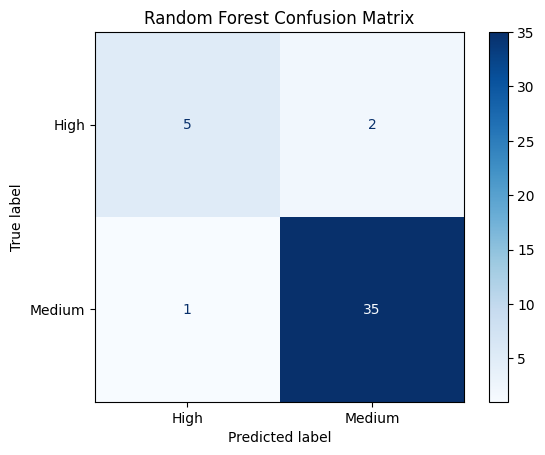

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:\n", classification_report(y_test, y_pred_rf))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

9. XGBOOST MODEL

XGBoost Results:
               precision    recall  f1-score   support

        High       0.71      0.71      0.71         7
      Medium       0.94      0.94      0.94        36

    accuracy                           0.91        43
   macro avg       0.83      0.83      0.83        43
weighted avg       0.91      0.91      0.91        43



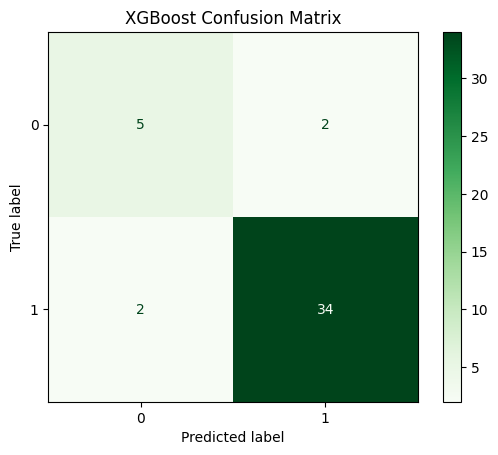

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled) # Use resampled data for fitting the encoder
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_resampled, y_train_encoded)
y_pred_xgb_encoded = xgb_model.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

print("XGBoost Results:\n", classification_report(y_test, y_pred_xgb))
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test_encoded, cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.show()

10. LIGHTGBM MODEL

[LightGBM] [Info] Number of positive: 140, number of negative: 140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1931
[LightGBM] [Info] Number of data points in the train set: 280, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

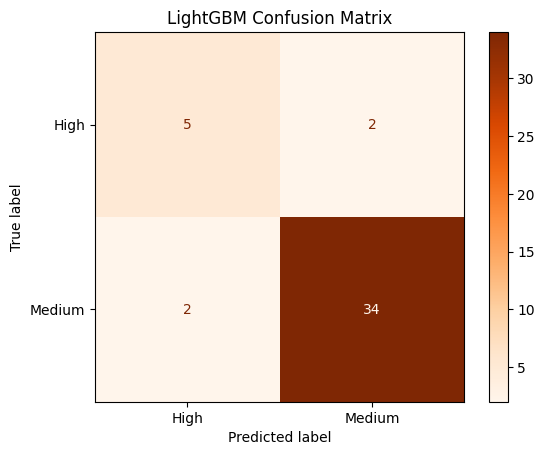

In [ ]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_resampled, y_train_resampled)
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Results:\n", classification_report(y_test, y_pred_lgbm))
ConfusionMatrixDisplay.from_estimator(lgbm_model, X_test, y_test, cmap='Oranges')
plt.title("LightGBM Confusion Matrix")
plt.show()

11. FEATURE IMPORTANCE (XGBoost)



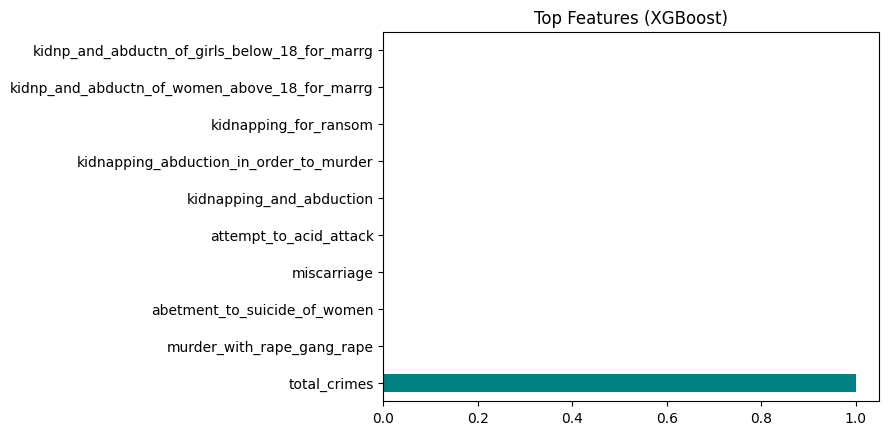

In [ ]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top Features (XGBoost)")
plt.show()

12. SHAP EXPLAINABILITY

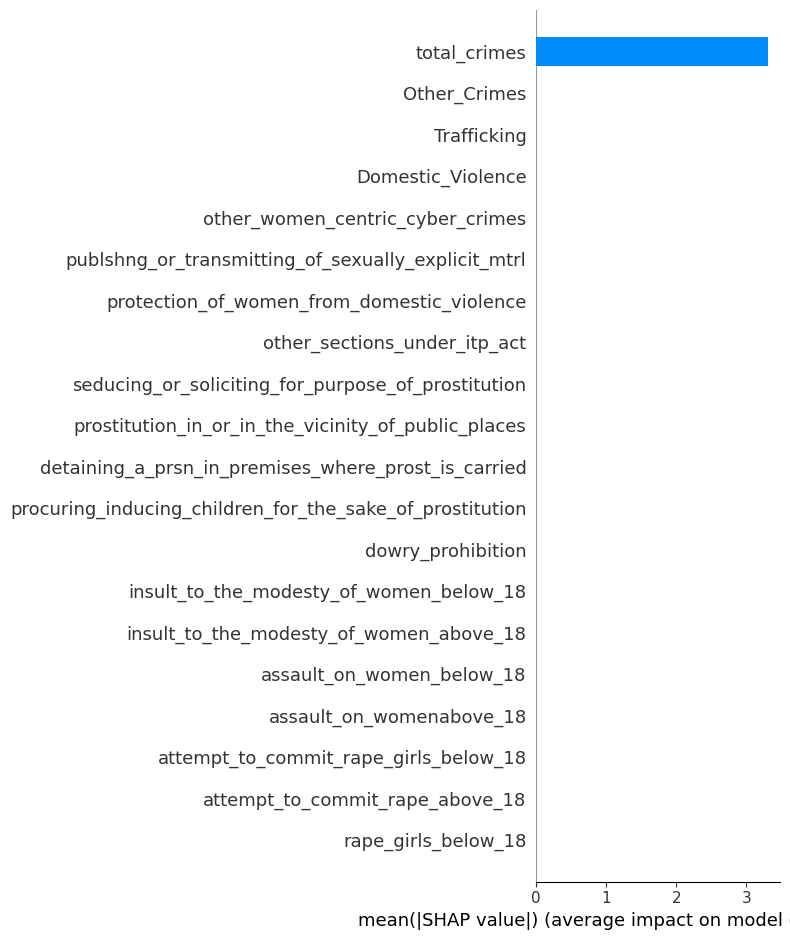

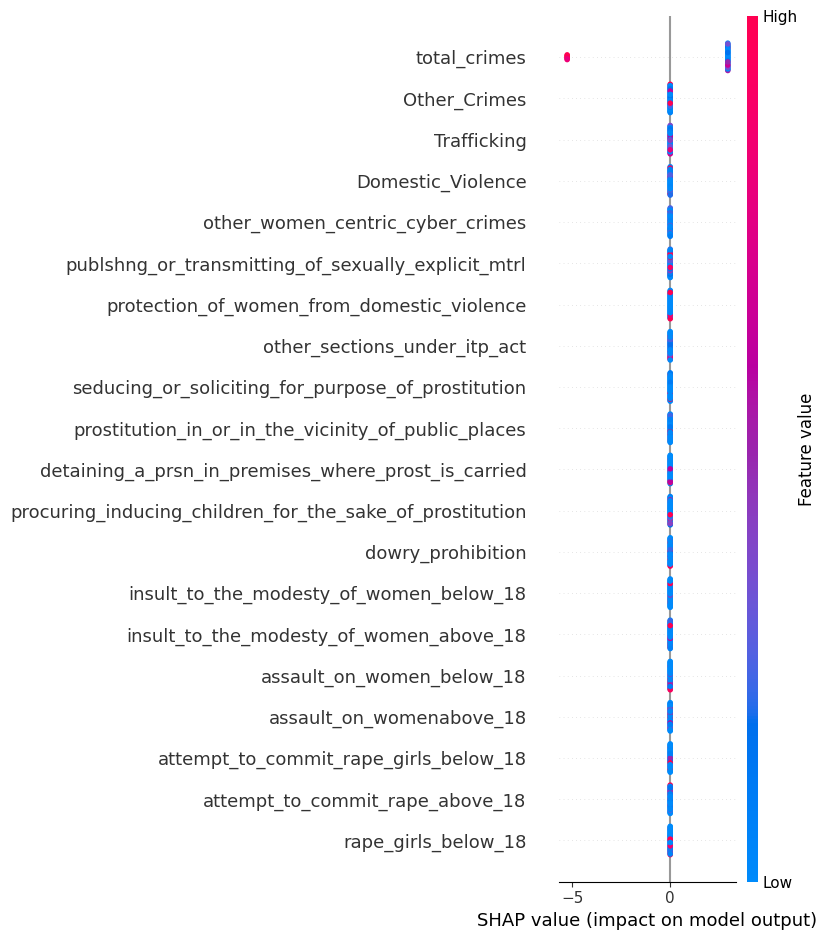

In [ ]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)

13. VISUALIZATIONS

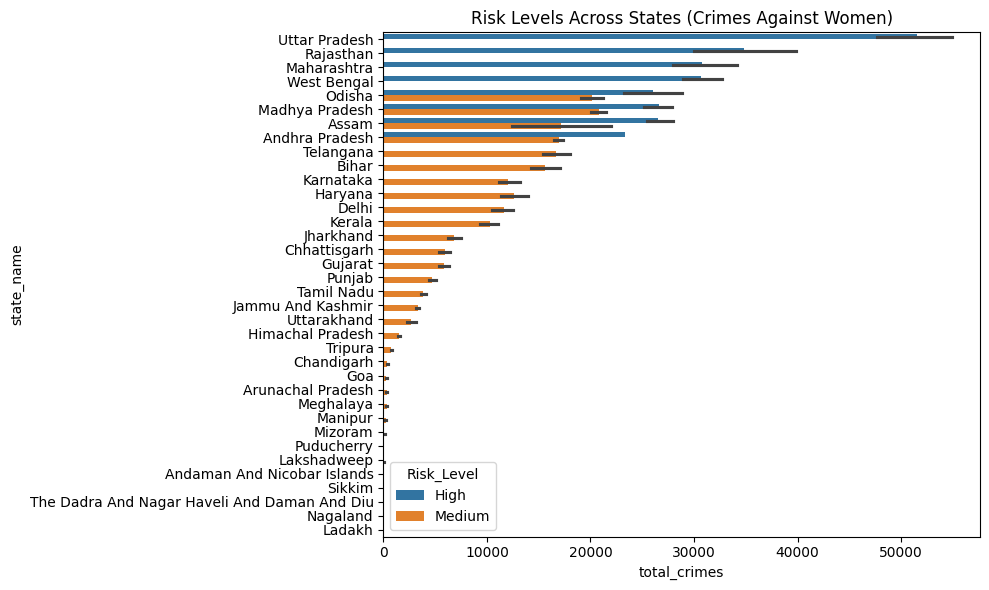

Pie Chart


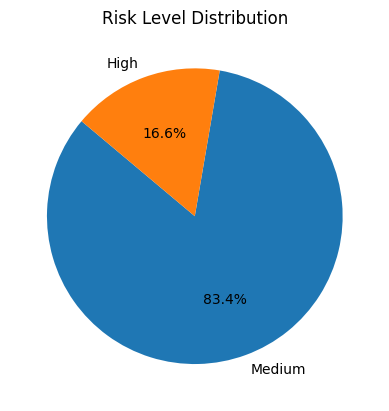

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='total_crimes', y='state_name', hue='Risk_Level', data=gdf.sort_values('total_crimes', ascending=False))
plt.title("Risk Levels Across States (Crimes Against Women)")
plt.tight_layout()
plt.show()
print("Pie Chart")
risk_counts = gdf['Risk_Level'].value_counts()
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Risk Level Distribution")
plt.show()

14.  ACCURACY RESULTS

In [ ]:
from sklearn.metrics import accuracy_score

# After Random Forest prediction
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# After XGBoost prediction
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# After LightGBM prediction
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))


Random Forest Accuracy: 0.9302325581395349
XGBoost Accuracy: 0.9069767441860465
LightGBM Accuracy: 0.9069767441860465


In [ ]:
print(X.columns)  # Make sure no column is directly derived from Risk_Level


Index(['murder_with_rape_gang_rape', 'abetment_to_suicide_of_women',
       'miscarriage', 'attempt_to_acid_attack', 'kidnapping_and_abduction',
       'kidnapping_abduction_in_order_to_murder', 'kidnapping_for_ransom',
       'kidnp_and_abductn_of_women_above_18_for_marrg',
       'kidnp_and_abductn_of_girls_below_18_for_marrg',
       'procuration_of_minor_girls', 'importation_of_girls_from_foreign',
       'kidnapping_and_abduction_of_women_others', 'selling_of_minor_girls',
       'buying_of_minor_girls', 'rape_women_above_18', 'rape_girls_below_18',
       'attempt_to_commit_rape_above_18',
       'attempt_to_commit_rape_girls_below_18', 'assault_on_womenabove_18',
       'assault_on_women_below_18', 'insult_to_the_modesty_of_women_above_18',
       'insult_to_the_modesty_of_women_below_18', 'dowry_prohibition',
       'procuring_inducing_children_for_the_sake_of_prostitution',
       'detaining_a_prsn_in_premises_where_prost_is_carried',
       'prostitution_in_or_in_the_vicinity

In [ ]:
!pip install imblearn

15. Handling Oversampling using SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of original training data:", X_train.shape)
print("Shape of resampled training data:", X_train_resampled.shape)
print("Distribution of Risk_Level in original training data:\n", y_train.value_counts())
print("Distribution of Risk_Level in resampled training data:\n", y_train_resampled.value_counts())

Shape of original training data: (168, 34)
Shape of resampled training data: (280, 34)
Distribution of Risk_Level in original training data:
 Risk_Level
Medium    140
High       28
Name: count, dtype: int64
Distribution of Risk_Level in resampled training data:
 Risk_Level
Medium    140
High      140
Name: count, dtype: int64


16. Tuning the hyperparameters of RandomForest, XGBoost, and LightGBM models using grid search with cross-validation and comparing their performance.

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [31, 50, 100]
}

 Performing grid search with cross-validation



In [ ]:
from sklearn.model_selection import GridSearchCV

# RandomForest
rf_model = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train_resampled, y_train_resampled)
print("Best parameters for RandomForest:", grid_search_rf.best_params_)

# XGBoost
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='accuracy')
grid_search_xgb.fit(X_train_resampled, y_train_encoded)
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)

# LightGBM
lgbm_model = LGBMClassifier(random_state=42)
grid_search_lgbm = GridSearchCV(lgbm_model, param_grid_lgbm, cv=5, scoring='accuracy')
grid_search_lgbm.fit(X_train_resampled, y_train_resampled)
print("Best parameters for LightGBM:", grid_search_lgbm.best_params_)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive g

In [ ]:
import pandas as pd

df = pd.read_csv('/content/districtwise-crime-against-women-2017-onwards.csv')
display(df.head())

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder_with_rape_gang_rape,dowry_deaths,abetment_to_suicide_of_women,miscarriage,acid_attack,attempt_to_acid_attack,cruelty_by_husband_or_his_relatives,kidnapping_and_abduction,kidnapping_abduction_in_order_to_murder,kidnapping_for_ransom,kidnp_and_abductn_of_women_above_18_for_marrg,kidnp_and_abductn_of_girls_below_18_for_marrg,procuration_of_minor_girls,importation_of_girls_from_foreign,kidnapping_and_abduction_of_women_others,human_trafficking,selling_of_minor_girls,buying_of_minor_girls,rape_women_above_18,rape_girls_below_18,attempt_to_commit_rape_above_18,attempt_to_commit_rape_girls_below_18,assault_on_womenabove_18,assault_on_women_below_18,insult_to_the_modesty_of_women_above_18,insult_to_the_modesty_of_women_below_18,dowry_prohibition,procuring_inducing_children_for_the_sake_of_prostitution,detaining_a_prsn_in_premises_where_prost_is_carried,prostitution_in_or_in_the_vicinity_of_public_places,seducing_or_soliciting_for_purpose_of_prostitution,other_sections_under_itp_act,protection_of_women_from_domestic_violence,publshng_or_transmitting_of_sexually_explicit_mtrl,other_women_centric_cyber_crimes,child_rape,sexual_assault_of_children,child_sexual_harassment,use_of_child_for_pornography,offences_of_pocso_act,pocso_act_unnatural_offences,indecent_representation_of_women
0,0,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,0.0,14.0,55.0,0.0,0.0,0.0,471.0,11.0,0.0,4.0,7.0,25.0,16.0,0.0,3.0,2.0,0.0,0.0,20.0,23.0,10.0,1.0,408.0,9.0,7.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
1,1,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,0.0,8.0,24.0,1.0,0.0,0.0,212.0,5.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,6.0,18.0,4.0,5.0,163.0,5.0,12.0,0.0,28.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,1.0,0.0,0.0,0.0,0.0
2,2,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,0.0,15.0,134.0,0.0,0.0,0.0,481.0,1.0,0.0,0.0,1.0,6.0,15.0,0.0,0.0,2.0,0.0,0.0,23.0,18.0,4.0,2.0,490.0,5.0,59.0,1.0,7.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,15.0,2.0,3.0,0.0,0.0,1.0,0.0
3,3,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,0.0,10.0,18.0,0.0,1.0,0.0,601.0,10.0,0.0,0.0,4.0,0.0,6.0,0.0,1.0,0.0,0.0,0.0,19.0,89.0,9.0,3.0,465.0,42.0,124.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,4,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,0.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0


17. Evaluation of the tuned models


Tuned Random Forest Results:
               precision    recall  f1-score   support

        High       0.83      0.71      0.77         7
      Medium       0.95      0.97      0.96        36

    accuracy                           0.93        43
   macro avg       0.89      0.84      0.86        43
weighted avg       0.93      0.93      0.93        43



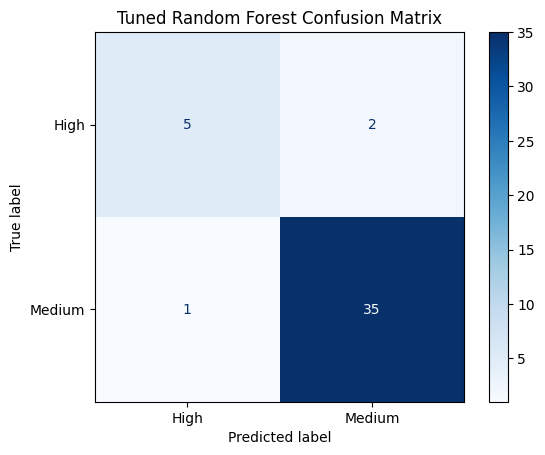

Tuned XGBoost Results:
               precision    recall  f1-score   support

        High       0.71      0.71      0.71         7
      Medium       0.94      0.94      0.94        36

    accuracy                           0.91        43
   macro avg       0.83      0.83      0.83        43
weighted avg       0.91      0.91      0.91        43



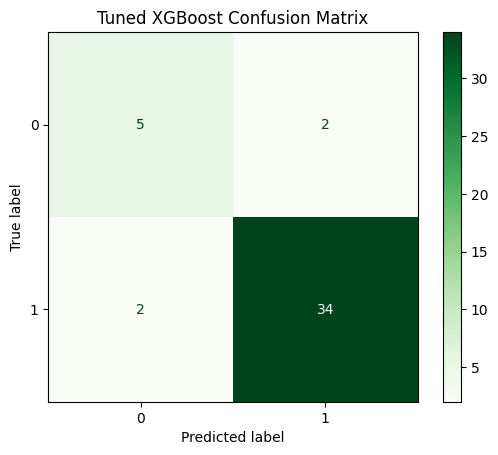

Tuned LightGBM Results:
               precision    recall  f1-score   support

        High       0.71      0.71      0.71         7
      Medium       0.94      0.94      0.94        36

    accuracy                           0.91        43
   macro avg       0.83      0.83      0.83        43
weighted avg       0.91      0.91      0.91        43



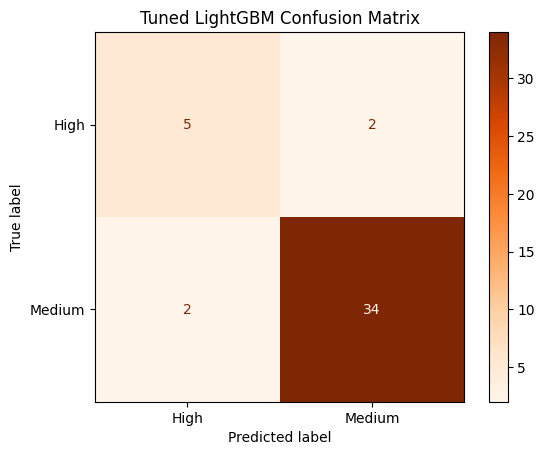

In [ ]:
# Evaluate tuned RandomForest
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test)

print("Tuned Random Forest Results:\n", classification_report(y_test, y_pred_rf_tuned))
ConfusionMatrixDisplay.from_estimator(best_rf_model, X_test, y_test, cmap='Blues')
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

# Evaluate tuned XGBoost
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb_tuned_encoded = best_xgb_model.predict(X_test)
y_pred_xgb_tuned = le.inverse_transform(y_pred_xgb_tuned_encoded) # Inverse transform to original labels

print("Tuned XGBoost Results:\n", classification_report(y_test, y_pred_xgb_tuned))
ConfusionMatrixDisplay.from_estimator(best_xgb_model, X_test, y_test_encoded, cmap='Greens')
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

# Evaluate tuned LightGBM
best_lgbm_model = grid_search_lgbm.best_estimator_
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test)

print("Tuned LightGBM Results:\n", classification_report(y_test, y_pred_lgbm_tuned))
ConfusionMatrixDisplay.from_estimator(best_lgbm_model, X_test, y_test, cmap='Oranges')
plt.title("Tuned LightGBM Confusion Matrix")
plt.show()

18. Comparing Model Performance(accuracy and other relevant metrics)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each tuned model
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned, average='weighted')
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned, average='weighted')
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned, average='weighted')

accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned, average='weighted')
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned, average='weighted')
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned, average='weighted')

accuracy_lgbm_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)
precision_lgbm_tuned = precision_score(y_test, y_pred_lgbm_tuned, average='weighted')
recall_lgbm_tuned = recall_score(y_test, y_pred_lgbm_tuned, average='weighted')
f1_lgbm_tuned = f1_score(y_test, y_pred_lgbm_tuned, average='weighted')

# Create a DataFrame to display the results
results = pd.DataFrame({
    'Model': ['Random Forest (Tuned)', 'XGBoost (Tuned)', 'LightGBM (Tuned)'],
    'Accuracy': [accuracy_rf_tuned, accuracy_xgb_tuned, accuracy_lgbm_tuned],
    'Precision (Weighted)': [precision_rf_tuned, precision_xgb_tuned, precision_lgbm_tuned],
    'Recall (Weighted)': [recall_rf_tuned, recall_xgb_tuned, recall_lgbm_tuned],
    'F1-Score (Weighted)': [f1_rf_tuned, f1_xgb_tuned, f1_lgbm_tuned]
})

display(results)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Random Forest (Tuned),0.930233,0.927614,0.930233,0.928027
1,XGBoost (Tuned),0.906977,0.906977,0.906977,0.906977
2,LightGBM (Tuned),0.906977,0.906977,0.906977,0.906977


19. Apply smote to the training data to handle class imbalance


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Shape of original training data:", X_train.shape)
print("Shape of resampled training data:", X_train_resampled.shape)
print("Distribution of Risk_Level in original training data:\n", y_train.value_counts())
print("Distribution of Risk_Level in resampled training data:\n", y_train_resampled.value_counts())

Shape of original training data: (168, 34)
Shape of resampled training data: (280, 34)
Distribution of Risk_Level in original training data:
 Risk_Level
Medium    140
High       28
Name: count, dtype: int64
Distribution of Risk_Level in resampled training data:
 Risk_Level
Medium    140
High      140
Name: count, dtype: int64


20. Training models on balanced data


In [ ]:
# Train tuned RandomForest on resampled data
best_rf_model_resampled = grid_search_rf.best_estimator_
best_rf_model_resampled.fit(X_train_resampled, y_train_resampled)

# Train tuned XGBoost on resampled data
best_xgb_model_resampled = grid_search_xgb.best_estimator_
best_xgb_model_resampled.fit(X_train_resampled, y_train_encoded)

# Train tuned LightGBM on resampled data
best_lgbm_model_resampled = grid_search_lgbm.best_estimator_
best_lgbm_model_resampled.fit(X_train_resampled, y_train_resampled)

[LightGBM] [Info] Number of positive: 140, number of negative: 140
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1931
[LightGBM] [Info] Number of data points in the train set: 280, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(learning_rate=0.01, n_estimators=300, random_state=42)

21. Evaluation of models on the test set



Tuned Random Forest (Resampled) Results:
               precision    recall  f1-score   support

        High       0.83      0.71      0.77         7
      Medium       0.95      0.97      0.96        36

    accuracy                           0.93        43
   macro avg       0.89      0.84      0.86        43
weighted avg       0.93      0.93      0.93        43



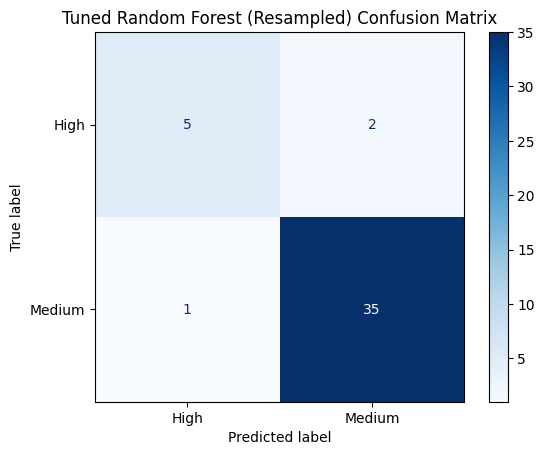

Tuned XGBoost (Resampled) Results:
               precision    recall  f1-score   support

        High       0.71      0.71      0.71         7
      Medium       0.94      0.94      0.94        36

    accuracy                           0.91        43
   macro avg       0.83      0.83      0.83        43
weighted avg       0.91      0.91      0.91        43



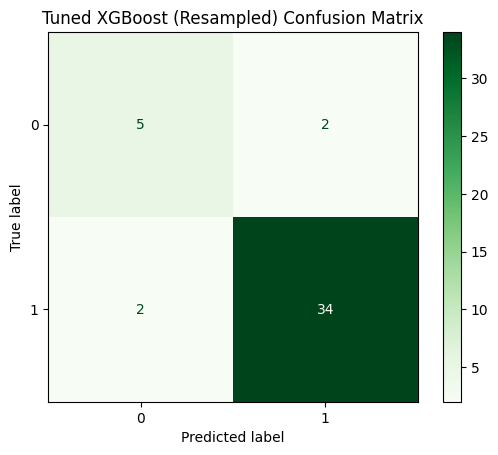

Tuned LightGBM (Resampled) Results:
               precision    recall  f1-score   support

        High       0.71      0.71      0.71         7
      Medium       0.94      0.94      0.94        36

    accuracy                           0.91        43
   macro avg       0.83      0.83      0.83        43
weighted avg       0.91      0.91      0.91        43



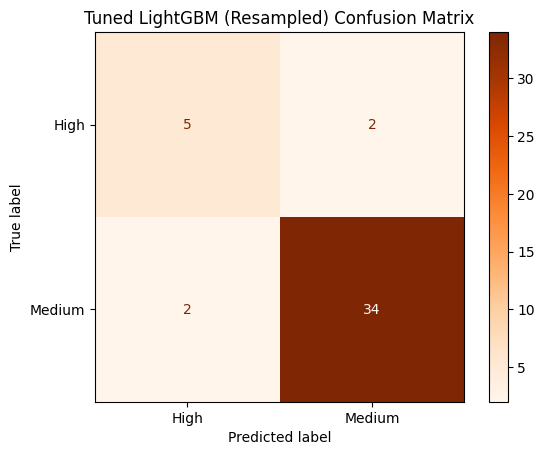

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate tuned RandomForest on resampled data predictions
y_pred_rf_resampled = best_rf_model_resampled.predict(X_test)
print("Tuned Random Forest (Resampled) Results:\n", classification_report(y_test, y_pred_rf_resampled))
ConfusionMatrixDisplay.from_estimator(best_rf_model_resampled, X_test, y_test, cmap='Blues')
plt.title("Tuned Random Forest (Resampled) Confusion Matrix")
plt.show()

# Evaluate tuned XGBoost on resampled data predictions
y_pred_xgb_resampled_encoded = best_xgb_model_resampled.predict(X_test)
y_pred_xgb_resampled = le.inverse_transform(y_pred_xgb_resampled_encoded)
print("Tuned XGBoost (Resampled) Results:\n", classification_report(y_test, y_pred_xgb_resampled))
ConfusionMatrixDisplay.from_estimator(best_xgb_model_resampled, X_test, y_test_encoded, cmap='Greens')
plt.title("Tuned XGBoost (Resampled) Confusion Matrix")
plt.show()

# Evaluate tuned LightGBM on resampled data predictions
y_pred_lgbm_resampled = best_lgbm_model_resampled.predict(X_test)
print("Tuned LightGBM (Resampled) Results:\n", classification_report(y_test, y_pred_lgbm_resampled))
ConfusionMatrixDisplay.from_estimator(best_lgbm_model_resampled, X_test, y_test, cmap='Oranges')
plt.title("Tuned LightGBM (Resampled) Confusion Matrix")
plt.show()

 22. Comparing performance with and without balancing(SMOTE)



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each tuned model trained with SMOTE
accuracy_rf_resampled = accuracy_score(y_test, y_pred_rf_resampled)
precision_rf_resampled = precision_score(y_test, y_pred_rf_resampled, average='weighted')
recall_rf_resampled = recall_score(y_test, y_pred_rf_resampled, average='weighted')
f1_rf_resampled = f1_score(y_test, y_pred_rf_resampled, average='weighted')

accuracy_xgb_resampled = accuracy_score(y_test, y_pred_xgb_resampled)
precision_xgb_resampled = precision_score(y_test, y_pred_xgb_resampled, average='weighted')
recall_xgb_resampled = recall_score(y_test, y_pred_xgb_resampled, average='weighted')
f1_xgb_resampled = f1_score(y_test, y_pred_xgb_resampled, average='weighted')

accuracy_lgbm_resampled = accuracy_score(y_test, y_pred_lgbm_resampled)
precision_lgbm_resampled = precision_score(y_test, y_pred_lgbm_resampled, average='weighted')
recall_lgbm_resampled = recall_score(y_test, y_pred_lgbm_resampled, average='weighted')
f1_lgbm_resampled = f1_score(y_test, y_pred_lgbm_resampled, average='weighted')

# Create a DataFrame to display the results for models trained with SMOTE
results_resampled = pd.DataFrame({
    'Model': ['Random Forest (Tuned + SMOTE)', 'XGBoost (Tuned + SMOTE)', 'LightGBM (Tuned + SMOTE)'],
    'Accuracy': [accuracy_rf_resampled, accuracy_xgb_resampled, accuracy_lgbm_resampled],
    'Precision (Weighted)': [precision_rf_resampled, precision_xgb_resampled, precision_lgbm_resampled],
    'Recall (Weighted)': [recall_rf_resampled, recall_xgb_resampled, recall_lgbm_resampled],
    'F1-Score (Weighted)': [f1_rf_resampled, f1_xgb_resampled, f1_lgbm_resampled]
})

# Combine the results DataFrames
combined_results = pd.concat([results, results_resampled], ignore_index=True)

display(combined_results)

,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted)
0,Random Forest (Tuned),0.930233,0.927614,0.930233,0.928027
1,XGBoost (Tuned),0.906977,0.906977,0.906977,0.906977
2,LightGBM (Tuned),0.906977,0.906977,0.906977,0.906977
3,Random Forest (Tuned + SMOTE),0.930233,0.927614,0.930233,0.928027
4,XGBoost (Tuned + SMOTE),0.906977,0.906977,0.906977,0.906977
5,LightGBM (Tuned + SMOTE),0.906977,0.906977,0.906977,0.906977
